# Preprocess Dosage Sensitivity Region and Gene Data
* Dosage sensitivity data from [ClinGen](https://search.clinicalgenome.org/kb/downloads)
* Used the Archived 2025-07-29 dosage sensitivity [gene](https://ftp.clinicalgenome.org/archive/20241220/ClinGen_haploinsufficiency_gene_GRCh38.bed) and [region](https://ftp.clinicalgenome.org/archive/20241220/ClinGen_haploinsufficiency_gene_GRCh38.bed) files with haploinsufficiency (HI) and triplosensitivity (TS) scores equal to 3 ("sufficient evidence" tier)

In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import plotly.graph_objects as go

In [2]:
dosage_gene_path = "clingen_dosage/ClinGen_gene_curation_list_GRCh38.tsv"
dosage_region_path = "clingen_dosage/ClinGen_region_curation_list_GRCh38.tsv"

In [3]:
dosage_gene_df = (
    pd.read_csv(dosage_gene_path, delimiter='\t', header=5)
    .rename(columns=lambda col: col.strip('#')) #remove comment character from header
)
dosage_region_df = (
    pd.read_csv(dosage_region_path, delimiter='\t', header=5)
    .rename(columns=lambda col: col.strip('#'))
)

In [4]:
dosage_gene_df['feature_type'] = 'gene'
dosage_region_df['feature_type'] = 'region'

dosage_gene_df['feature_name'] = dosage_gene_df['Gene Symbol']
dosage_gene_df['feature_id'] = dosage_gene_df['Gene ID']

dosage_region_df['feature_name'] = dosage_region_df['ISCA Region Name']
dosage_region_df['feature_id'] = dosage_region_df['ISCA ID']

dosage_df = pd.concat(
    [dosage_gene_df, dosage_region_df]
)
len(dosage_df)

2114

In [5]:
dosage_df = dosage_df.query("`Genomic Location` != 'tbd'")
len(dosage_df)

2106

In [6]:
dosage_df['chromosome'] = dosage_df['Genomic Location'].str.extract(
    r"chr([\dXY]+)\:"
)

dosage_df['genomic_start'] = dosage_df['Genomic Location'].str.extract(
    r"\:(\d+)\-"
).astype(int)
dosage_df['genomic_stop'] = dosage_df['Genomic Location'].str.extract(
    r"\d+\-(\d+)"
).astype(int)

In [7]:
dosage_df['Haploinsufficiency Score'] = (
    dosage_df['Haploinsufficiency Score']
    .fillna(-1)
    .astype(int)
)

dosage_df['Haploinsufficiency Description'] = (
    dosage_df['Haploinsufficiency Description']
    .fillna('None')
)

dosage_df['Triplosensitivity Score'] = (
    dosage_df['Triplosensitivity Score']
    .fillna(-1)
    .replace("Not yet evaluated", -1)
    .astype(int)
)

dosage_df['Triplosensitivity Description'] = (
    dosage_df['Triplosensitivity Description']
    .fillna('None')
)

In [8]:
(
    dosage_df
    .groupby(['feature_type', 'Haploinsufficiency Score', 'Haploinsufficiency Description'])
    .size()
    .unstack(level=0, fill_value=0)
)

,feature_type,gene,region
Haploinsufficiency Score,Haploinsufficiency Description,,
-1,None,0,2
0,No evidence available,289,91
1,Little evidence for dosage pathogenicity,134,8
2,Some evidence for dosage pathogenicity,10,6
3,Sufficient evidence for dosage pathogenicity,397,48
30,Gene associated with autosomal recessive phenotype,731,3
40,Dosage sensitivity unlikely,35,352


In [9]:
(
    dosage_df
    .groupby(['feature_type', 'Triplosensitivity Score', 'Triplosensitivity Description'])
    .size()
    .unstack(level=0, fill_value=0)
)

feature_type                                                          gene  \
Triplosensitivity Score Triplosensitivity Description                        
-1                      None                                             1   
                        Not yet evaluated                              272   
 0                      No evidence available                         1308   
 1                      Little evidence for dosage pathogenicity         9   
 2                      Some evidence for dosage pathogenicity           1   
 3                      Sufficient evidence for dosage pathogenicity     2   
 40                     Dosage sensitivity unlikely                      3   

feature_type                                                          region  
Triplosensitivity Score Triplosensitivity Description                         
-1                      None                                               1  
                        Not yet evaluated                                  0  
 0                      No evidence available                            368  
 1                      Little evidence for dosage pathogenicity          19  
 2                      Some evidence for dosage pathogenicity            10  
 3                      Sufficient evidence for dosage pathogenicity      20  
 40                     Dosage sensitivity unlikely                       92

In [10]:
feat_df_hi = (
    dosage_df
    .query("`Haploinsufficiency Score` == 3")
)[['feature_type', 'feature_name', 'feature_id', 'chromosome', 'genomic_start', 'genomic_stop']]
len(feat_df_hi)

445

In [11]:
feat_df_ts = (
    dosage_df
    .query("`Triplosensitivity Score` == 3") # score is a string type in this table
)[['feature_type', 'feature_name', 'feature_id', 'chromosome', 'genomic_start', 'genomic_stop']]
len(feat_df_ts)

22

In [12]:
# load NCH and ClinVar CNVs
nch_df = pd.read_csv("cnv_data/NCH-microarray-CNVs-cleaned.csv")
clinvar_df = pd.read_csv("cnv_data/ClinVar-CNVs-normalized.csv.gzip", compression='gzip')

# NCH to ClinVar matching with respect to dosage sensitivity

## Matching NCH copy loss CNVs to ClinVar haploinsufficiency overlapping variants

In [13]:
# create subset dataframes for copy gain/loss
nch_df_loss = nch_df.query("copy_number_max < 2")
len(nch_df_loss)

3995

In [14]:
#get copy loss ClinVar CNVs
clinvar_df_loss = clinvar_df.query("absolute_copies < 2") 
len(clinvar_df_loss)

18856

In [15]:
# cross reference with all HI features
clinvar_hi_df = (
    clinvar_df_loss
    .merge( 
        right=feat_df_hi,
        how='inner',
        left_on='chr',
        right_on='chromosome',
        suffixes=('__clinvar', '__ts')
    )
)
len(clinvar_hi_df)

435706

In [16]:
# keep partial overlap with HI region
clinvar_hi_df = (
    clinvar_hi_df
    #.query("genomic_start.between(start_38, stop_38)") # overlapping with beginning of region
    #.query("genomic_stop.between(start_38, stop_38)") #overlapping with end of region
    .query("genomic_start.between(start_38, stop_38) | genomic_stop.between(start_38, stop_38)")
)
len(clinvar_hi_df)

14949

In [17]:
clinvar_df_hi_overlap = pd.DataFrame(
    clinvar_hi_df
    .groupby(clinvar_df.columns.to_list())
    ['feature_name']
    .nunique()
    .reset_index()
)
len(clinvar_df_hi_overlap)

4542

In [18]:
nch_clinvar_hi_match_df = (
    nch_df_loss.add_prefix('nch_')
    .merge(
        right=clinvar_df_hi_overlap.add_prefix('clinvar_'),
        left_on='nch_chromosome',
        right_on='clinvar_chr',
        how='inner'
    )
    .query("(nch_start_38 <= clinvar_stop_38) & (clinvar_start_38 <= nch_stop_38)")
)

len(nch_clinvar_hi_match_df)

103635

## Matching NCH copy gain CNVs to ClinVar triplosensitivity overlapping variants

In [19]:
# get NCH copy gain CNVs
nch_df_gain = nch_df.query("copy_number_min > 2")
len(nch_df_gain)

4261

In [20]:
#get copy gain ClinVar CNVs
clinvar_df_gain = clinvar_df.query("absolute_copies > 2") 
len(clinvar_df_gain)

19330

In [21]:
# cross reference with all TS features
clinvar_ts_df = (
    clinvar_df_gain
    .merge( 
        right=feat_df_ts,
        how='inner',
        left_on='chr',
        right_on='chromosome',
        suffixes=('__clinvar', '__ts')
    )
)
len(clinvar_ts_df)

24526

In [22]:
# only keep total overlap with TS region
clinvar_ts_df = (
    clinvar_ts_df
    .query("start_38 <= genomic_start")
    .query("stop_38 >= genomic_stop")
)
len(clinvar_ts_df)

852

In [23]:
clinvar_df_ts_overlap = pd.DataFrame(
    clinvar_ts_df
    .groupby(clinvar_df.columns.to_list())
    ['feature_name']
    .nunique()
    .reset_index()
)
len(clinvar_df_ts_overlap)

505

In [24]:
nch_clinvar_ts_match_df = (
    nch_df_gain.add_prefix('nch_')
    .merge(
        right=clinvar_df_ts_overlap.add_prefix('clinvar_'),
        left_on='nch_chromosome',
        right_on='clinvar_chr',
        how='inner'
    )
    .query("(nch_start_38 <= clinvar_stop_38) & (clinvar_start_38 <= nch_stop_38)")
)
len(nch_clinvar_ts_match_df)

33300

### Figure: Varying Jaccard BP Overlap Score, how many CN gain variants in NCH dataset have a ClinVar match containing a Triplosensitivity region/gene?

In [25]:
def jaccard_similarity_figure_dosage(
    dosage_match_df: pd.DataFrame,
    title: str,
):
    dosage_match_df['jaccard_score_bp_overlap'] = (
        (
            dosage_match_df[['nch_stop_38', 'clinvar_stop_38']].min(axis=1)
            - dosage_match_df[['nch_start_38', 'clinvar_start_38']].max(axis=1)
        )
        / (
            dosage_match_df[['nch_stop_38', 'clinvar_stop_38']].max(axis=1)
            - dosage_match_df[['nch_start_38', 'clinvar_start_38']].min(axis=1)
        )
    )

    thrs = list(np.arange(0, 1.001, 0.001))
    match_fractions = []
    n_total = dosage_match_df['nch_variant'].nunique()
    for thr in thrs:
        if thr == 1: # handle edge case at maximum value of Jaccard score
            op = "=="
        else:
            op = ">="
        n_matches = (
            dosage_match_df
            .query(f"jaccard_score_bp_overlap {op} {thr}")
            ['nch_variant'].nunique()
        )
        match_fractions.append(
            100 * (n_matches / n_total)
        )
    
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=thrs, y=match_fractions, marker_color='darkblue'
    ))
    fig.update_xaxes(
        title_text='Jaccard Similarity Threshold',
        linecolor='black',
        ticks='outside',
        dtick=0.1,
        range=[0,1]
    )
    
    fig.update_yaxes(
        title_text='% of Variants with Match',
        linecolor='black',
        ticks='outside',
        range=[0,100]
    )
    fig.update_layout(
        height=400,
        width=600,
        title_text=title,
        plot_bgcolor='white',
        legend=dict(
            bordercolor='black',
            borderwidth=2,
            x=0.99,
            xanchor='right'
        )
    )
    fig.show()

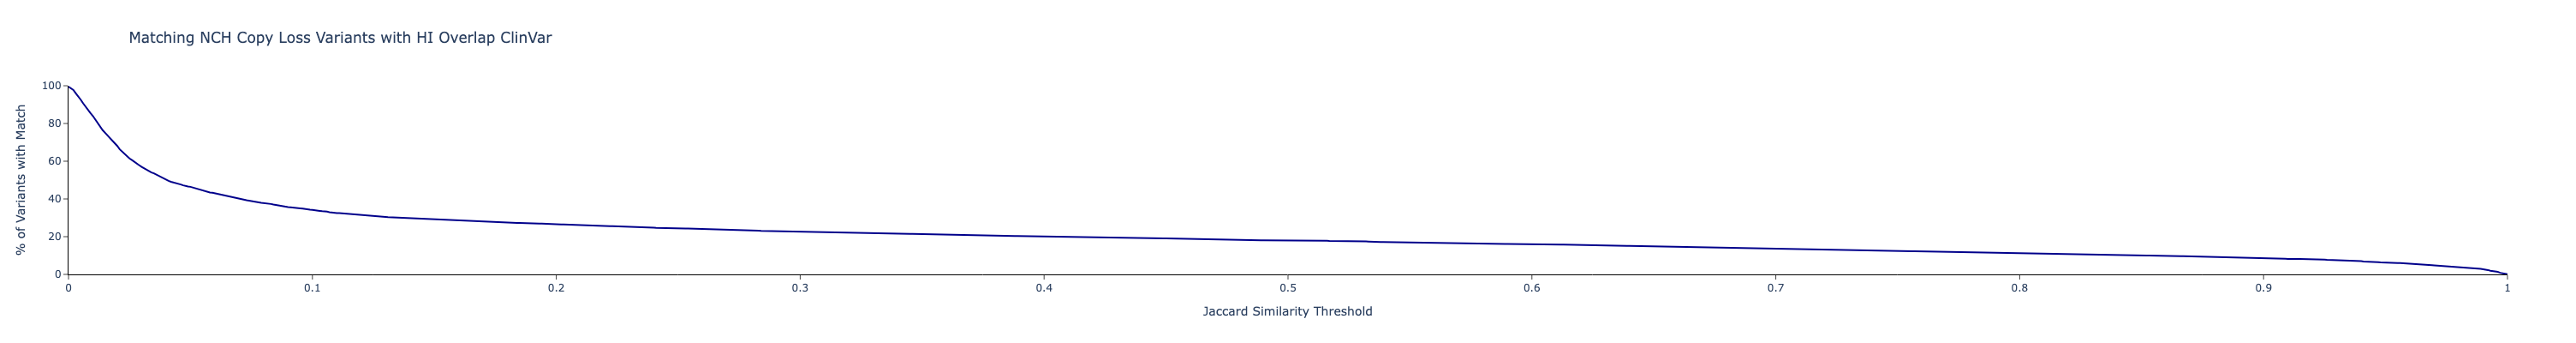

In [26]:
jaccard_similarity_figure_dosage(
    dosage_match_df=nch_clinvar_hi_match_df,
    title='Matching NCH Copy Loss Variants with HI Overlap ClinVar',
)

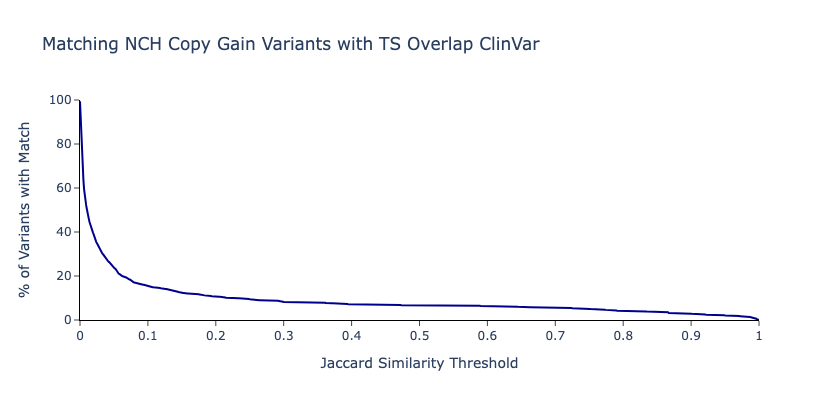

In [27]:
jaccard_similarity_figure_dosage(
    dosage_match_df=nch_clinvar_ts_match_df,
    title='Matching NCH Copy Gain Variants with TS Overlap ClinVar',
)